In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

np.random.seed(42)
torch.manual_seed(42)

In [2]:
data = {
    "temperature": [10, 15, 22, 25, 28, 35, 38],
    "humidity":    [30, 40, 50, 55, 60, 70, 80],
    "y":           [ 0,  0,  1,  1,  1,  0,  0]
}

df = pd.DataFrame(data)
df

,temperature,humidity,y
0,10,30,0
1,15,40,0
2,22,50,1
3,25,55,1
4,28,60,1
5,35,70,0
6,38,80,0


In [3]:
X_raw = df[["temperature", "humidity"]].to_numpy(dtype=np.float32)
X_raw

array([[10., 30.],
       [15., 40.],
       [22., 50.],
       [25., 55.],
       [28., 60.],
       [35., 70.],
       [38., 80.]], dtype=float32)

In [4]:
y = df["y"].to_numpy(dtype=np.float32).reshape(-1, 1)
y

array([[0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.]], dtype=float32)

In [5]:
X_mean = X_raw.mean(axis=0, keepdims=True)
X_std = X_raw.std(axis=0, keepdims=True)

print(f"X_mean={X_mean}, X_std={X_std}")

X_mean=[[24.714285 55.      ]], X_std=[[ 9.345959 15.811388]]


In [6]:
X_norm = (X_raw - X_mean) / X_std
X_norm

array([[-1.5744008 , -1.5811388 ],
       [-1.0394102 , -0.9486833 ],
       [-0.29042336, -0.31622776],
       [ 0.03057098,  0.        ],
       [ 0.35156533,  0.31622776],
       [ 1.1005522 ,  0.9486833 ],
       [ 1.4215466 ,  1.5811388 ]], dtype=float32)

In [7]:
# X_tensor:
# 정규화된 NumPy배열 X_norm을 PyTorch Tensor로 변환합니다. (dtype=torch.float32: 32비트 실수)
# 이제부터 PyTorch 계산에는 X_tensor를 그대로 입력으로 사용합니다.
#
# 이번 Linear/optimizer 방식에서는 X_tensor 전체를 Linear 계층에 입력합니다.
# gradient 자동 계산 방식처럼 X1_norm, X2_norm을 따로 만들어 곱하지 않습니다.
# torch.nn.Linear가 X_tensor의 두 입력 컬럼을 한 번에 처리합니다.
#
# 단, X_tensor는 입력값이므로 학습을 통해 값이 바뀌는 대상은 아닙니다.
# 학습을 통해 갑싱 바뀌는 대상은 Linear계층 안의 weight와 bias입니다.
X_tensor = torch.tensor(X_norm, dtype=torch.float32)

In [8]:
# y_tensor:
# 정답 y도 PyTorch계산에 사용할 수 있도록 Tensor로 변환합니다.
y_tensor = torch.tensor(y, dtype=torch.float32)
y_tensor

tensor([[0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.]])

In [9]:
# Linear 계층을 만들기 바로 전에 난수를 고정하빈다.
# 이렇게 하면 실행할 때마다 Linear안의 weight, bias 초기값이 똑같이 재현됩니다.
# 즉, 수업 중에 실행 결과가 매번 달라져서 헷갈리는 일을 줄일 수 있습니다.
torch.manual_seed(42)

# hidden_layer:
# 입력 2개(온도, 습도)를 받아 히든 뉴런 2개의 선형값을 만듭니다.
# 직접 구현 방식에서 사람이 직접 만들던 히든층의 weight/bias 역할을
# 이제 torch.nn.Linear가 내부에서 관리합니다.
hidden_layer = torch.nn.Linear(2, 2)

# output_layer:
# 히든 뉴런 2개의 출력을 받아 최종 출력 1개의 선형값을 만듭니다.
# 직접 구현 방식에서 사람이 직접 만들던 출력층의 weight/bias 역할을
# 이제 torch.nn.Linear가 내부에서 관리합니다.
output_layer = torch.nn.Linear(2, 1)

print("hidden_layer:", hidden_layer)
print("ouput_layer:", output_layer)

hidden_layer: Linear(in_features=2, out_features=2, bias=True)
ouput_layer: Linear(in_features=2, out_features=1, bias=True)


In [10]:
def bce_cost_torch(y, z_output):
    epsilon = 1e-7
    z_output = torch.clamp(z_output, epsilon, 1- epsilon)
    cost = -torch.mean(
        y * torch.log(z_output) + (1 - y) * torch.log(1 - z_output)
    )
    return cost

In [11]:
# 학습 전에 순전파를 한 번 실행해서 shape와 초기 Cost를 확인합니다. (확인용)
# 아직 학습을 시작하기 전이므로, 여기서 계산되는 Cost는
# 무작위 초기 weight/bias로 만든 예측 결과의 Cost입니다.

# hidden_layer(X_tensor):
# X_tensor 안에는 입력 2개가 들어 있습니다.
# 여기서 설명을 쉽게 하기 위해 X_tensor의 두 입력 컬럼을 개념적으로 다음처럼 부르겠습니다.
# - X1_norm: 정규화된 온도 입력
# - X2_norm: 정규화된 습도 입력
#
# 주의:
# # X1_norm, X2_norm은 실제 코드에 새로 만드는 변수가 아닙니다.
# # X_tensor 안의 첫 번째 입력 컬럼과 두 번째 입력 컬럼을 설명하기 위한 이름입니다.
#
# 직접 구현 방식에서는 히든 뉴런 2개를 아래처럼 직접 계산했습니다.
# # (bias는 곱하는 값이 아니라 마지막에 더하는 값입니다.)
#
# H_hidden_1 = X1_norm * a11 + X2_norm * a12 + b1
# H_hidden_2 = X1_norm * a21 + X2_norm * a22 + b2
#
# AI 개발자로 성장하려면 위 "입력 x weight + bias" 선형 계산식의 의미는 반드시 이해해야 합니다.
# 다만 이번 Linear/optimizer 방식에서는 이 식을 사람이 직접 코드로 쓰지 않고,
# hidden_layer가 내부에서 같은 종류의 계산을 한 번에 수행합니다.
H_hidden = hidden_layer(X_tensor)

In [12]:
# 히든층 선형값 H_hidden을 sigmoid에 통과시킵니다.
#
# 직접 구현 방식의 흐름:
# z_hidden_1 = sigmoid(H_hidden_1)
# z_hidden_2 = sigmoid(H_hidden_2)
#
# z_hidden은 0~1 사이 값입니다.
# 단, z_hidden은 최종 예측확률이 아닙니다.
# output_layer로 넘어가는 히든층의 중간 출력값입니다.
z_hidden = torch.sigmoid(H_hidden)

In [13]:
# output_layer(z_hidden):
# 히든 뉴런 2개의 출력값을 받아 최종 선형값 H_output을 계산합니다.
#
# 직접 구현 방식에서는 아래처럼 직접 계산했습니다.
#
# H_output = z_hidden_1 * a31 + z_hidden_2 * a32 + b3
#
# 여기서 a31, a32는 출력층 weight 역할이고,
# b3는 출력층 bias 역할입니다.
#
# AI 개발자로 성장하려면 이 출력층 선형 계산식도 반드시 이해해야 합니다.
# 다만 이번 방식에서는 output_layer가 내부에서 이 계산을 수행합니다.
H_output = output_layer(z_hidden)

In [14]:
# 출력층 선형값 H_output을 sigmoid에 통과시켜 최종 예측확률 z_output을 만듭니다.
#
# 직접 구현 방식의 흐름:
# z_output = sigmoid(H_output)
#
# z_output은 최종 예측확률입니다.
# z_output이 0.5 이상이면 클래스 1,
# z_output이 0.5 미만이면 클래스 0으로 예측할 수 있습니다.
z_output = torch.sigmoid(H_output)

In [15]:
# 정답 y_tensor와 예측확률 z_output을 비교해 BCE Cost를 계산합니다.
#
# BCE Cost는 이진 분류에서 예측확률이 정답과 얼마나 다른지 계산하는 값입니다.
#
# 개념적으로는 다음 흐름입니다.
# y_tensor와 z_output의 차이를 Cost로 계산
# -> Cost가 작아지도록 weight와 bias를 수정
#
# 이 Cost가 학습을 거치며 줄어드는지 확인할 것입니다.
cost = bce_cost_torch(y_tensor, z_output)

print("H_hidden shape:", H_hidden.shape)
print("z_output shape:", z_output.shape)
print("초기 cost:", cost.item())

H_hidden shape: torch.Size([7, 2])
z_output shape: torch.Size([7, 1])
초기 cost: 0.7983762621879578


In [16]:
learning_rate = 0.5
epochs = 3000
cost_history = []
training_log = []

# optimizer: hidden_layer와 ouput_layer의 파라미터를 모두 합쳐서 넘깁니다.
# hidden_layer.parameters(): hidden_layer안의 weight와 bias목록
# output_layer.parameters(): output_layer안의 weight와 bias목록
# list(...) + list(...): 두 목록을 하나로 합쳐 optimizer에게 전달
# opimizer는 이 목록을 보고 어떤 weight와 bias를 수정해야 하는지 알 수 있습니다.
optimizer = torch.optim.SGD(
    list(hidden_layer.parameters()) + list(output_layer.parameters()),
    lr = learning_rate
)

for epoch in range(epochs):
    # (1) 이전 epoch 에서 남아 있는 gradient 를 비웁니다.
    #     PyTorch 의 gradient 는 기본적으로 누적되므로,
    #     새 gradient 를 계산하기 전에 먼저 0 으로 만들어야 합니다.
    #
    #     주의: optimizer.zero_grad() 는 weight와 bias 자체를 0으로 만드는 것이 아니라,
    #          각 파라미터에 쌓여 있는 gradient만 비우는 것입니다.
    #
    #     이전 방식에서는 for p in params: p.grad.zero_() 를 직접 반복했습니다.
    #     이번 Linear/optimizer 방식에서는 optimizer.zero_grad() 가 optimizer 가 관리하는 모든 파라미터의
    #     .grad 를 한 번에 0 으로 비웁니다.
    optimizer.zero_grad()

    # (2) 순전파
    #     이번 방식에서는 X_tensor 전체를 hidden_layer 에 넣습니다.
    #     Linear 가 입력 컬럼 2개(온도, 습도)를 한 번에 처리합니다.
    #
    #     설명을 쉽게 하기 위해 X_tensor의 두 입력 컬럼을 개념적으로 X1_norm(온도), X2_norm(습도)라고 부릅니다.
    #     (X1_norm, X2_norm 은 실제 코드 변수가 아니라 설명용 이름입니다.)
    #
    #     직접 구현 방식에서는 히든 뉴런 2개를 아래처럼 직접 계산했습니다.
    #     (bias는 곱하는 값이 아니라 마지막에 더하는 값입니다.)
    #     H_hidden_1 = X1_norm * a11 + X2_norm * a12 + b1
    #     H_hidden_2 = X1_norm * a21 + X2_norm * a22 + b2
    #     이 "입력 x weight + bias" 식의 의미는 반드시 이해해야 하며,
    #     이번 방식에서는 hidden_layer 가 같은 계산을 내부에서 한 번에 수행합니다.
    H_hidden = hidden_layer(X_tensor)       # 입력 2개 -> 히든 뉴런 2개 선형값 (한 번에)

    #     z_hidden_1 = sigmoid(H_hidden_1), z_hidden_2 = sigmoid(H_hidden_2)
    #     z_hidden 은 0~1 사이 값이지만 최종 예측확률이 아니라, output_layer 로 넘어가는 중간값입니다.
    z_hidden = torch.sigmoid(H_hidden)      # 히든층 출력 (0~1, 중간값)

    #     직접 구현 방식의 출력층 계산:
    #     H_output = z_hidden_1 * a31 + z_hidden_2 * a32 + b3
    #     (a31, a32 는 출력층 weight 역할, b3 는 출력층 bias 역할)
    H_output = output_layer(z_hidden)       # 히든 뉴런 2개 -> 최종 선형값 1개

    #     z_output = sigmoid(H_output)
    #     z_output 이 최종 예측확률입니다. (0.5 이상이면 클래스 1, 미만이면 클래스 0)
    z_output = torch.sigmoid(H_output)      # 최종 예측확률 (0~1)

    # (3) Cost 계산
    #     정답 y_tensor 와 예측확률 z_output 을 비교해 BCE Cost 를 계산합니다.
    #     학습은 이 Cost 가 작아지도록 weight 와 bias 를 수정하는 과정입니다.
    cost = bce_cost_torch(y_tensor, z_output)
    cost_history.append(cost.item())

    # (4) gradient 자동 계산
    #     cost.backward() 를 실행하면 Linear 안의 weight 와 bias 에 대한 gradient 가 계산됩니다.
    #     (cost.backward() 는 gradient 를 계산할 뿐, 파라미터를 직접 수정하지는 않습니다.)
    #     계산된 gradient 는 hidden_layer.weight.grad, hidden_layer.bias.grad,
    #     output_layer.weight.grad, output_layer.bias.grad 에 저장됩니다.
    cost.backward()

    # (5) 대표 epoch 에서 cost, 파라미터, gradient 기록
    #     step()을 실행하면 파라미터가 바뀌므로,
    #     업데이트되기 전의 값과 gradient를 보기 위해 step() 전에 기록합니다.
    #     (그래서 이 기록은 반드시 cost.backward() 이후, optimizer.step() 이전에 합니다.)
    #     정상 학습 흐름에서는 grad 가 None 이 아니어야 하지만,
    #     안전을 위해 None 이면 float("nan") 으로 기록합니다.
    if epoch % 500 == 0:
        training_log.append({
            "epoch": epoch,
            "cost": cost.item(),
            "hidden_w_00": hidden_layer.weight[0, 0].item(),
            "hidden_b_0": hidden_layer.bias[0].item(),
            "output_w_00": output_layer.weight[0, 0].item(),
            "output_b_0": output_layer.bias[0].item(),
            "hidden_w_00_grad": hidden_layer.weight.grad[0, 0].item()
                if hidden_layer.weight.grad is not None else float("nan"),
            "hidden_b_0_grad": hidden_layer.bias.grad[0].item()
                if hidden_layer.bias.grad is not None else float("nan"),
            "output_w_00_grad": output_layer.weight.grad[0, 0].item()
                if output_layer.weight.grad is not None else float("nan"),
            "output_b_0_grad": output_layer.bias.grad[0].item()
                if output_layer.bias.grad is not None else float("nan"),
        })

        print(f"epoch={epoch:4d}, cost={cost.item():.6f}")
        
    # (6) 파라미터 업데이트
    #     optimizer.step() 은 cost.backward() 로 계산된 gradient 를 이용해 weight 와 bias 를 수정합니다.
    #
    #     직접 구현 방식에서는 아래와 같은 업데이트를 사람이 직접 작성했습니다.
    #     parameter = parameter - learning_rate * parameter.grad
    #     예 (대표 예시):
    #     a11 = a11 - learning_rate * grad_a11
    #     b1 = b1 - learning_rate * grad_b1
    #     (모든 파라미터 업데이트 식을 길게 나열하지는 않습니다. 위는 대표 예시입니다.)
    #
    #     이번 Linear/optimizer 방식에서는 optimizer.step() 이
    #     Linear 안의 weight 와 bias 에 대해 같은 종류의 업데이트를 대신 수행합니다.
    optimizer.step()


epoch=   0, cost=0.798376
epoch= 500, cost=0.095704
epoch=1000, cost=0.029810
epoch=1500, cost=0.017091
epoch=2000, cost=0.011887
epoch=2500, cost=0.009083


In [17]:
training_log_df = pd.DataFrame(training_log)
training_log_df

,epoch,cost,hidden_w_00,hidden_b_0,output_w_00,output_b_0,hidden_w_00_grad,hidden_b_0_grad,output_w_00_grad,output_b_0_grad
0,0,0.798376,0.540610,-0.154930,-0.344258,0.623345,-0.001521,-0.008272,0.111398,0.235739
1,500,0.095704,2.858203,-3.742404,-6.046050,-2.426894,-0.004335,0.005304,0.015467,0.008551
2,1000,0.029810,3.440474,-4.471745,-8.297037,-3.634869,-0.001341,0.001706,0.005574,0.002917
3,1500,0.017091,3.689094,-4.788891,-9.362078,-4.188004,-0.000752,0.000961,0.003318,0.001712
4,2000,0.011887,3.843720,-4.986603,-10.057146,-4.545533,-0.000513,0.000656,0.002350,0.001205
5,2500,0.009083,3.954681,-5.128524,-10.572248,-4.809307,-0.000386,0.000493,0.001815,0.000928


first cost: 0.7983762621879578
last cost: 0.007340637035667896
cost decreased: True


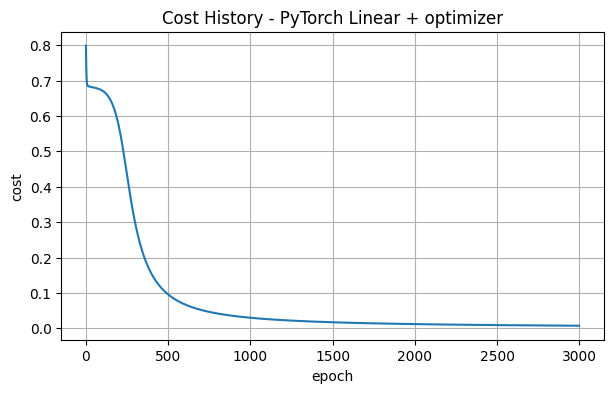

In [19]:
# 학습 후, cost가 실제로 줄었는지 숫자로 확인합니다.
print("first cost:", cost_history[0])
print("last cost:", cost_history[-1])
print("cost decreased:", cost_history[-1] < cost_history[0])

# cost 감소 그래프
plt.figure(figsize=(7, 4))
plt.plot(cost_history)
plt.xlabel("epoch")
plt.ylabel("cost")
plt.title("Cost History - PyTorch Linear + optimizer")
plt.grid(True)
plt.show()

In [20]:
# 학습이 끝난 파라미터로 최종 예측을 확인합니다.
# 예측만 할 때는 gradient가 필요 없으므로 torch.no_grad() 안에서 실행합니다.
with torch.no_grad():
    H_hidden = hidden_layer(X_tensor)
    z_hidden = torch.sigmoid(H_hidden)

    H_output = output_layer(z_hidden)
    z_output = torch.sigmoid(H_output)

    # z_output은 0~1 사이의 예측확률입니다.
    # 0.5 이상이면 1, 0.5 미만이면 0으로 판단합니다.
    pred = (z_output >= 0.5).float()
    accuracy = (pred == y_tensor).float().mean()

# 결과 표 만들기
result_df = df[["temperature", "humidity", "y"]].copy()

# z_output 은 PyTorch Tensor 입니다.
# 표에 넣기 위해 추적을 끊고(detach) NumPy배열로 바꿉니다.
z_output_np = z_output.detach().numpy()
z_output_1d = z_output_np.reshape(-1)
result_df["z_output"] = z_output_1d.round(4)

# pred도 같은 방식으로 단계별로 나눠서 넣습니다.
pred_np = pred.detach().numpy()
pred_1d = pred_np.reshape(-1)
result_df["pred"] = pred_1d.astype(int)

print("accuracy:", accuracy.item())
result_df

accuracy: 1.0


,temperature,humidity,y,z_output,pred
0,10,30,0,0.0066,0
1,15,40,0,0.0102,0
2,22,50,1,0.9907,1
3,25,55,1,0.9953,1
4,28,60,1,0.9911,1
5,35,70,0,0.0072,0
6,38,80,0,0.0042,0
